<a href="https://colab.research.google.com/github/AaravJain626/ML-DL-using-PyTorch/blob/main/Computer_vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Computer Vision Using PyTorch

In [1]:
import torch
from torch import nn

#import torchvision
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt

print(torch.__version__)
print(torchvision.__version__)


2.10.0+cpu
0.25.0+cpu


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

##1.Getting  data
fashion MNIST from torchvision.datasets


In [3]:
train_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=None
)
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    target_transform=None
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 18.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 305kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.60MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 21.7MB/s]


In [4]:
len(test_data),len(train_data)

(10000, 60000)

In [5]:
image,label = train_data[0]
# image,label

In [6]:
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [7]:
class_to_idx = train_data.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [8]:
image.shape

torch.Size([1, 28, 28])

Text(0.5, 1.0, '5')

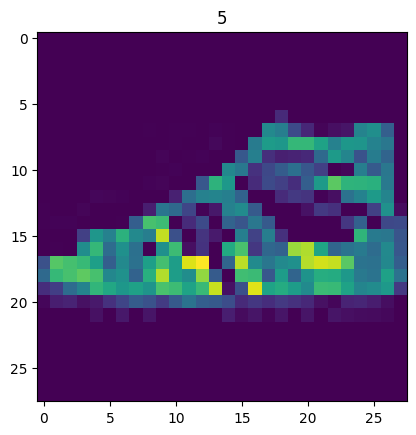

In [9]:
image,label = train_data[7028]
plt.imshow(image.squeeze())
plt.title(label)

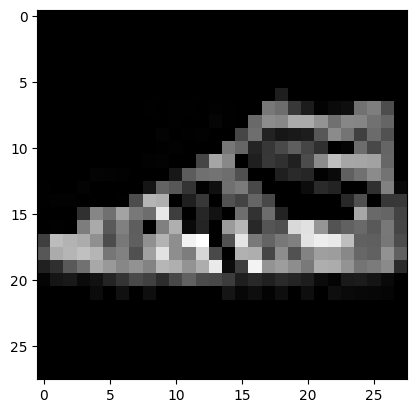

In [10]:
plt.imshow(image.squeeze(),cmap="gray")

##2.Making Dataloader

In [11]:
from torch.utils.data import DataLoader
BATCH_SIZE = 32
train_dataloader = DataLoader(dataset=train_data,
                              batch_size=BATCH_SIZE,
                              shuffle=True,
                              )
test_dataloader = DataLoader(dataset=test_data,
                             batch_size=BATCH_SIZE,
                             shuffle=False)


In [12]:
train_dataloader.batch_sampler

In [13]:
print(f"DataLoaders:{train_dataloader,test_dataloader}")
print(f"Length of train_dataloader{len(train_dataloader)} Batches of {BATCH_SIZE}")
print(f"Length of test_dataloader:{len(test_dataloader)} Batches of {BATCH_SIZE}")


DataLoaders:(<torch.utils.data.dataloader.DataLoader object at 0x7b29537c4ec0>, <torch.utils.data.dataloader.DataLoader object at 0x7b295384be60>)
Length of train_dataloader1875 Batches of 32
Length of test_dataloader:313 Batches of 32


In [14]:
#whats inside the dataloader
train_features_batch,train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape,train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

## 3.Model 0:Building a Baseline model

In [15]:
#Create a Flatten layer
flatten_model = nn.Flatten()

# single sample
x =train_features_batch[0]

#flatten the sample
output = flatten_model(x)

print(f"shape before flattening:{x.shape}->color chanel,height,width")
print(f"shape after flattening:{output.shape}->color channel,height*width")

shape before flattening:torch.Size([1, 28, 28])->color chanel,height,width
shape after flattening:torch.Size([1, 784])->color channel,height*width


In [16]:
class FashionMNISTModelV0(nn.Module):
  def __init__(self,
              input_shape: int,
              hidden_units: int,
              output_shape: int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape,
                  out_features=hidden_units),
        nn.Linear(in_features=hidden_units,
                  out_features=output_shape)

    )
  def forward(self, x):
    return self.layer_stack(x)


In [21]:
torch.manual_seed(42)

#Setting up model with input params
model_0 = FashionMNISTModelV0(
    input_shape=784,#=28*28
    hidden_units=10,#units in Hidden layer
    output_shape=len(class_names)
).to("cpu")


In [22]:
dummy_x = torch.rand([1,1,28,28])
model_0(dummy_x)

tensor([[-0.0315,  0.3171,  0.0531, -0.2525,  0.5959,  0.2112,  0.3233,  0.2694,
         -0.1004,  0.0157]], grad_fn=<AddmmBackward0>)

###3.1 Loss,optimizer and evaluation

In [ ]:
import requests
from pathlib import Path